# **Introduction**

In this notebook, I want to explore how multicollinearity affects a Linear Regression model.

Linear Regression assumes that the features are not highly correlated with each other. But what happens when some features have a very strong correlation? Does it affect the model coefficients? Does it make the predictions less stable?

To find out, we start with a baseline model using all numerical features. Then, identify highly correlated features and build another model using fewer features to reduce multicollinearity.

Finally, we'll compare both models and see how multicollinearity affects the coefficients and prediction performance.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error

In [2]:
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", None)

In [3]:
df = pd.read_csv('/kaggle/input/datasets/vipullrathod/fish-market/Fish.csv')
df.head(3)

,Species,Weight,Length1,Length2,Length3,Height,Width
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961


**Target:** Weight

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159 entries, 0 to 158
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Species  159 non-null    object 
 1   Weight   159 non-null    float64
 2   Length1  159 non-null    float64
 3   Length2  159 non-null    float64
 4   Length3  159 non-null    float64
 5   Height   159 non-null    float64
 6   Width    159 non-null    float64
dtypes: float64(6), object(1)
memory usage: 8.8+ KB


In [5]:
numerical_columns = df.select_dtypes(include=['number']).columns

In [6]:
target_column = "Weight"

numerical_columns_without_target = (
    df.select_dtypes(include=["number"])
      .columns
      .drop(target_column)
)

print(numerical_columns)

Index(['Weight', 'Length1', 'Length2', 'Length3', 'Height', 'Width'], dtype='object')


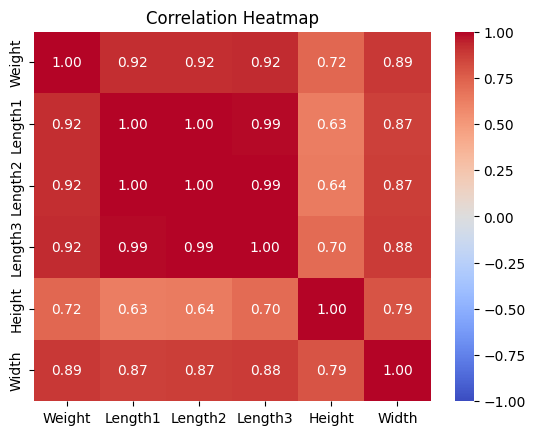

In [7]:
correlation = df[numerical_columns].corr()
sns.heatmap(correlation,
           annot=True,
           cmap='coolwarm',
           fmt='.2f',
           vmin=-1,
           vmax=1)
plt.title('Correlation Heatmap')
plt.show()

Seeing value 0.99 - 1 in the correlation heatmap, appears that the `Length1`, `Length2`, and `Length3` are the most multicollinear one. So we will use only one of them to compare with baseline model that use all numerical columns as features. 

In [8]:
df_shuffled = df.sample(frac=1, random_state=42)

split = int(0.9 * len(df_shuffled))

train_df = df_shuffled.iloc[:split]
test_df = df_shuffled.iloc[split:]

In [9]:
df_log_transform = df.copy()

df_log_transform[numerical_columns] = np.log1p(
    df_log_transform[numerical_columns]
)

In [10]:
# FIXED TEST SET
X_train, X_test, y_train, y_test = train_test_split(
    df_log_transform[numerical_columns_without_target],
    df_log_transform['Weight'],
    test_size=0.2,
    random_state=38
)

# Convert test target back to original scale
y_test_original = np.expm1(y_test)

Let's compare the difference between only using feature without 'too much' multicollinear vs using all features available.

# **Baseline**

In [11]:
# VALIDATION EXPERIMENT
random_states = [i for i in range(30)]
results_baseline = []

for random_state in random_states:

    X_train, X_val, y_train, y_val = train_test_split(
        df_log_transform[numerical_columns_without_target],
        df_log_transform['Weight'],
        test_size=0.2,
        random_state=random_state
    )

    model = LinearRegression()
    model.fit(X_train, y_train)

    # -------------------------
    # Validation evaluation
    # -------------------------
    y_val_pred = model.predict(X_val)

    y_val_pred_original = np.expm1(y_val_pred)
    y_val_original = np.expm1(y_val)

    val_r2 = r2_score(y_val_original, y_val_pred_original)
    val_mae = mean_absolute_error(y_val_original, y_val_pred_original)

    # -------------------------
    # Test evaluation
    # -------------------------
    y_test_pred = model.predict(X_test)

    y_test_pred_original = np.expm1(y_test_pred)

    test_r2 = r2_score(y_test_original, y_test_pred_original)
    test_mae = mean_absolute_error(y_test_original, y_test_pred_original)

    # -------------------------
    # Store results
    # -------------------------
    results_baseline.append({
        "Random State": random_state,
        "Intercept": model.intercept_,
        "Coefficient": model.coef_,

        "Validation R²": val_r2,
        "Validation MAE": val_mae,

        "Test R²": test_r2,
        "Test MAE": test_mae
    })


results_baseline_df = pd.DataFrame(results_baseline)

results_baseline_df.style.hide(axis="index")

Random State,Intercept,Coefficient,Validation R²,Validation MAE,Test R²,Test MAE
0,-3.299700,[-1.46934496 3.49919516 -0.46116116 0.71259767 1.15723052],0.940762,60.542503,0.962013,51.033808
1,-3.251753,[-0.96889994 3.31355527 -0.7734881 0.7823262 1.06411208],0.966516,36.315453,0.962131,50.066333
2,-3.661931,[-1.81559714 5.33686373 -1.76819305 0.89425807 0.7935395 ],0.959713,41.286020,0.967122,52.661975
3,-3.289134,[-1.3724312 3.62064228 -0.65119771 0.75732113 1.04714711],0.985012,21.607886,0.963646,50.044499
4,-3.742361,[-2.86596489 5.83147216 -1.21424208 0.78568003 0.90857191],0.983744,32.695809,0.966262,52.260378
5,-3.272881,[-2.09791031 4.29434109 -0.62529918 0.73669409 1.08195306],0.961430,37.025195,0.961637,50.253396
6,-3.882610,[-3.04795467 6.50750932 -1.57838551 0.85345987 0.65818748],0.955713,46.048277,0.967685,52.256864
7,-3.374466,[-1.87111187 4.01164446 -0.52727132 0.74563558 1.05333965],0.939909,41.660758,0.963748,50.388260
8,-3.873092,[-3.23149746 6.65514364 -1.58705551 0.86457872 0.71672689],0.957035,50.096033,0.967546,52.689256
9,-3.802220,[-2.4719704 5.74909059 -1.4729831 0.92274199 0.68891658],0.963210,41.077956,0.967038,53.038991


# **Drop Multicollinear Columns**

In [12]:
# VALIDATION EXPERIMENT
random_states = [i for i in range(30)]

results_non_multicollinear = []

for random_state in random_states:

    X_train, X_val, y_train, y_val = train_test_split(
        df_log_transform[['Length1', 'Width', 'Height']],
        df_log_transform['Weight'],
        test_size=0.1,
        random_state=random_state
    )

    model = LinearRegression()
    model.fit(X_train, y_train)

    # -------------------------
    # Validation evaluation
    # -------------------------
    y_val_pred = model.predict(X_val)

    y_val_pred_original = np.expm1(y_val_pred)
    y_val_original = np.expm1(y_val)

    val_r2 = r2_score(
        y_val_original,
        y_val_pred_original
    )

    val_mae = mean_absolute_error(
        y_val_original,
        y_val_pred_original
    )

    # -------------------------
    # Test evaluation
    # -------------------------
    y_test_pred = model.predict(X_test[['Length1', 'Width', 'Height']])

    y_test_pred_original = np.expm1(y_test_pred)

    test_r2 = r2_score(
        y_test_original,
        y_test_pred_original
    )

    test_mae = mean_absolute_error(
        y_test_original,
        y_test_pred_original
    )

    # -------------------------
    # Store results
    # -------------------------
    results_non_multicollinear.append({
        "Random State": random_state,
        "Intercept": model.intercept_,
        "Coefficient": model.coef_,

        "Validation R²": val_r2,
        "Validation MAE": val_mae,

        "Test R²": test_r2,
        "Test MAE": test_mae
    })


results_non_multicollinear_df = pd.DataFrame(
    results_non_multicollinear
)

results_non_multicollinear_df.style.hide(axis="index")

Random State,Intercept,Coefficient,Validation R²,Validation MAE,Test R²,Test MAE
0,-3.004746,[1.47433112 1.26916933 0.72024403],0.910012,64.465184,0.958056,50.924718
1,-3.014168,[1.4845279 1.2399579 0.72859848],0.985706,23.377367,0.958429,49.522124
2,-3.217034,[1.56683895 1.20408785 0.71378118],0.951504,46.780613,0.961954,50.004756
3,-2.991597,[1.47894872 1.23945906 0.72960483],0.983873,24.468907,0.958325,49.825475
4,-3.224267,[1.56970543 1.21406567 0.70505487],0.990515,24.958619,0.962139,50.059916
5,-3.245900,[1.57541045 1.17671802 0.73436448],0.953562,49.731376,0.961960,50.205177
6,-3.372264,[1.65459828 1.10617452 0.72849038],0.954602,54.421261,0.964512,50.400415
7,-2.989393,[1.47055747 1.26992114 0.71967034],0.903864,48.630200,0.957948,51.065760
8,-3.285312,[1.60113026 1.1651034 0.72325719],0.963389,53.502258,0.963183,50.263565
9,-3.255215,[1.57739736 1.14454278 0.76005496],0.942058,45.815096,0.961580,50.294220


# **Comparation Result**

In [13]:
coef_df = pd.DataFrame(
    results_baseline_df["Coefficient"].tolist(),
    columns=numerical_columns_without_target
)

In [14]:
coef_non_multicollinear_df = pd.DataFrame(
    results_non_multicollinear_df["Coefficient"].tolist(),
    columns=['Length1', 'Width', 'Height']
)

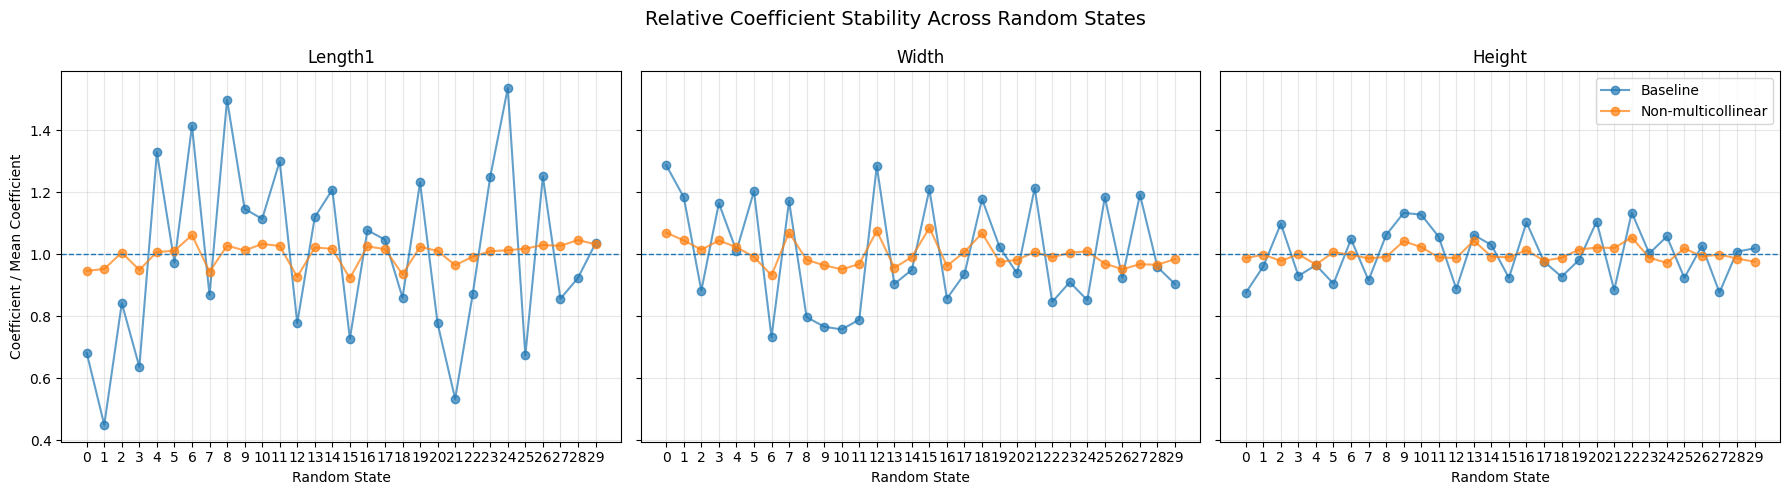

In [15]:
features = ['Length1', 'Width', 'Height']

baseline_norm = coef_df[features].div(
    coef_df[features].mean()
)

non_multicollinear_norm = coef_non_multicollinear_df[features].div(
    coef_non_multicollinear_df[features].mean()
)

fig, axes = plt.subplots(
    1,
    len(features),
    figsize=(18, 5),
    sharey=True
)

for i, feature in enumerate(features):

    axes[i].plot(
        random_states,
        baseline_norm[feature],
        marker='o',
        alpha=0.7,
        label='Baseline'
    )

    axes[i].plot(
        random_states,
        non_multicollinear_norm[feature],
        marker='o',
        alpha=0.7,
        label='Non-multicollinear'
    )

    axes[i].axhline(
        1,
        linestyle='--',
        linewidth=1
    )

    axes[i].set_title(feature)
    axes[i].set_xlabel("Random State")
    axes[i].set_xticks(random_states)
    axes[i].grid(alpha=0.3)

axes[0].set_ylabel("Coefficient / Mean Coefficient")
axes[-1].legend()

plt.suptitle(
    "Relative Coefficient Stability Across Random States",
    fontsize=14
)

plt.tight_layout()
plt.show()

There are inconsistency in coefficients between the baseline and the non-multicollinear one.

The interesting part is, the one who is unstable is the one who has multicollinear relationship rather than the other. Which proves the assumption that multicollinearity holds coefficient incosistency in linear regression model.

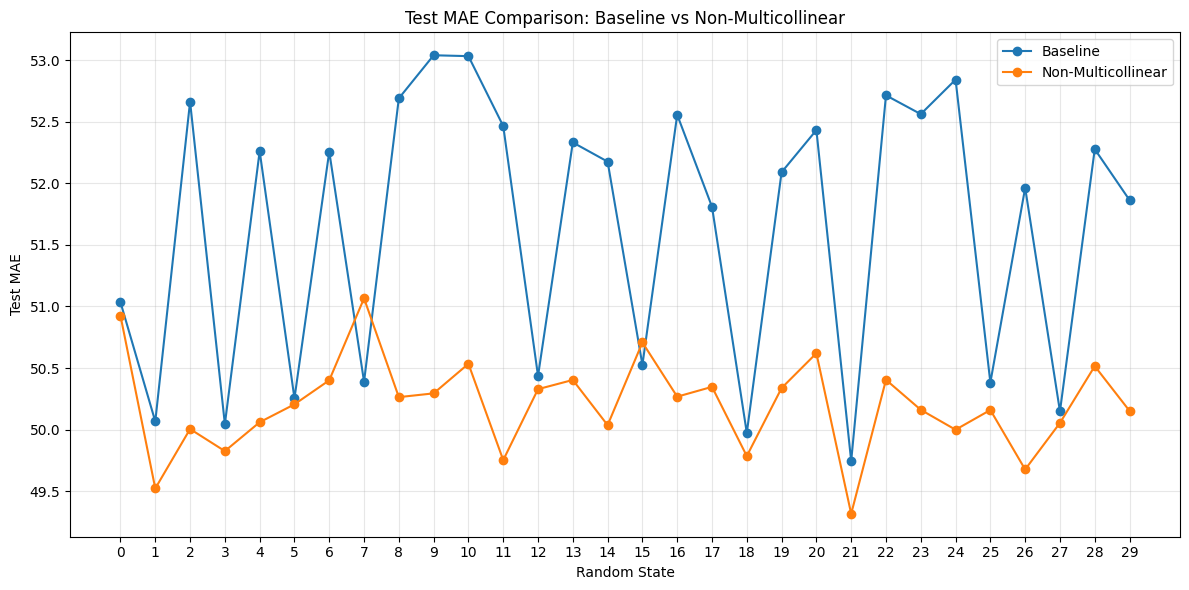

In [16]:
plt.figure(figsize=(12, 6))

plt.plot(
    results_baseline_df["Random State"],
    results_baseline_df["Test MAE"],
    marker="o",
    label="Baseline"
)

plt.plot(
    results_non_multicollinear_df["Random State"],
    results_non_multicollinear_df["Test MAE"],
    marker="o",
    label="Non-Multicollinear"
)

plt.xlabel("Random State")
plt.ylabel("Test MAE")
plt.title("Test MAE Comparison: Baseline vs Non-Multicollinear")
plt.xticks(range(30))
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Compare to baseline, using the same fixed test set, MAE from non multicollinear one is more stable. It conclude that multicollinearity holds instability in prediction result.

Also, see how the non multicollinear one mostly have lower MAE test compare to tthe baseline one? That's worth to note too. 

# **Conclusion**

So, what did we learn?

The highly correlated features, especially Length1, Length2, and Length3, showed noticeable differences in their coefficients compared to the model with reduced multicollinearity. This suggests that multicollinearity can make Linear Regression coefficients less stable and harder to interpret.

Using the same fixed test set, the model with less multicollinearity also showed a more stable MAE and, in several cases, performed better than the baseline model that used all numerical features.

So, even when multicollinearity does not always hurt prediction performance, it can make the model coefficients unstable and less reliable for interpretation. Reducing highly correlated features can therefore be useful, especially when we care about understanding the role of each feature, not just making predictions.